# PV Integration in a Distribution Network

## Voltage Impacts, Reverse Power Flow, and Smart-Inverter Mitigation

This project uses the IEEE 33-bus distribution test system in `pandapower`[1] to study how increasing solar PV penetration affects:

- feeder voltage profiles
- active-power losses
- the effect of PV location
- reverse active-power flow at high PV penetration
- reactive-power control using an illustrative Volt-VAR controller

The analysis uses steady-state AC power flow. PV penetration is expressed as installed PV active-power capacity divided by the feeder total active load.


## 1. Setup

Packages used throughout the notebook.

`pandapower` provides the distribution-network model and AC power-flow solver. `pandas` and `numpy` are used for data handling and calculations, while `matplotlib` is used for visualization.

In [2]:
# Install pandapower in Google Colab.
%%capture
!pip install pandapower

In [9]:
# Import the libraries used in the analysis.
import pandapower as pp
import pandapower.networks as pn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load and validate the IEEE 33-bus feeder

The IEEE 33-bus system is a radial distribution-network test case. It contains buses, loads, distribution lines, and an external grid.

Before adding PV, the base case is solved. This gives a reference against which every PV scenario can be compared.

In [10]:
# Load the IEEE 33-bus distribution test system.
net = pn.case33bw()

# Solve the base-case AC power flow.
pp.runpp(net)

print('Buses:', len(net.bus))
print('Lines:', len(net.line))
print('Loads:', len(net.load))
print('External grids:', len(net.ext_grid))

Buses: 33
Lines: 37
Loads: 32
External grids: 1


In [11]:
# Calculate the main base-case operating quantities.
min_voltage = net.res_bus.vm_pu.min()
max_voltage = net.res_bus.vm_pu.max()
total_loss_mw = net.res_line.pl_mw.sum()

total_p_load = net.load.p_mw.sum()
total_q_load = net.load.q_mvar.sum()
weakest_bus = net.res_bus.vm_pu.idxmin()

print(f'Total active load: {total_p_load:.4f} MW')
print(f'Total reactive load: {total_q_load:.4f} MVAr')
print(f'Minimum voltage: {min_voltage:.4f} p.u.')
print(f'Maximum voltage: {max_voltage:.4f} p.u.')
print(f'Total active-power losses: {total_loss_mw:.4f} MW')
print(f'Weakest bus: {weakest_bus}')

Total active load: 3.7150 MW
Total reactive load: 2.3000 MVAr
Minimum voltage: 0.9131 p.u.
Maximum voltage: 1.0000 p.u.
Total active-power losses: 0.2027 MW
Weakest bus: 17


In [45]:
# Summarize the line configuration.
# 'in_service' tells us whether a line participates in the power flow.
line_summary = net.line[
    ['from_bus', 'to_bus', 'length_km', 'r_ohm_per_km',
     'x_ohm_per_km', 'in_service', 'max_i_ka']
]

line_summary

,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,in_service,max_i_ka
0,0,1,1.0,0.0922,0.0470,True,99999.0
1,1,2,1.0,0.4930,0.2511,True,99999.0
2,2,3,1.0,0.3660,0.1864,True,99999.0
3,3,4,1.0,0.3811,0.1941,True,99999.0
4,4,5,1.0,0.8190,0.7070,True,99999.0
5,5,6,1.0,0.1872,0.6188,True,99999.0
6,6,7,1.0,0.7114,0.2351,True,99999.0
7,7,8,1.0,1.0300,0.7400,True,99999.0
8,8,9,1.0,1.0440,0.7400,True,99999.0
9,9,10,1.0,0.1966,0.0650,True,99999.0


### Base-case voltage profile

A distribution feeder normally experiences voltage drop as power is delivered away from the source. The plot below shows the voltage magnitude at every bus.


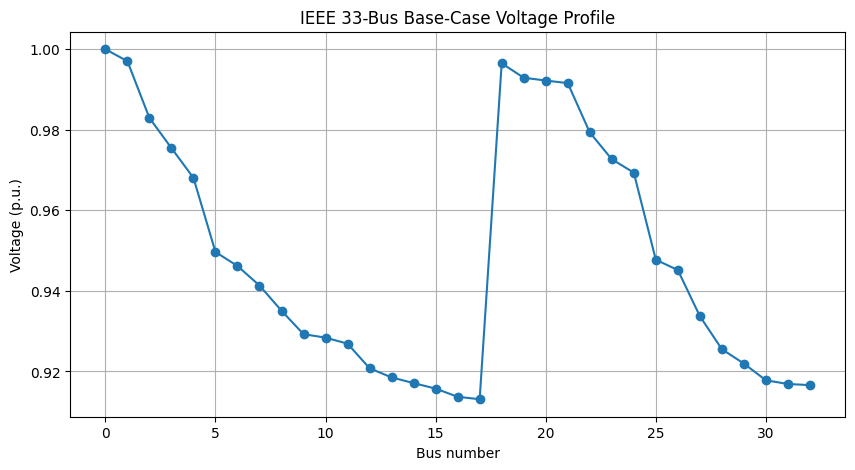

In [13]:
# Plot the base-case voltage profile.
plt.figure(figsize=(10, 5))

plt.plot(
    net.res_bus.index,
    net.res_bus.vm_pu,
    marker='o',
    label='Base case'
)

plt.xlabel('Bus number')
plt.ylabel('Voltage (p.u.)')
plt.title('IEEE 33-Bus Base-Case Voltage Profile')
plt.grid(True)
plt.show()

## 3. Experiment 1: Effect of increasing PV penetration

PV generator is connected at Bus 17 and its active-power output is increased.

The PV is initially operated at unity power factor, meaning `Q = 0 MVAr`. This isolates the effect of real-power injection before introducing reactive-power control.

PV penetration is calculated as:
$$
PV\ penetration = \frac{PV\ capacity}{Total\ feeder\ active\ load}\times100
$$

The feeder active load is 3.715 MW.

In [14]:
# Test increasing PV capacity at Bus 17.
# Q is set to zero so that only active-power injection is varied.
pv_sizes = [0, 0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.00]

pv_sweep_results = []

for pv_mw in pv_sizes:
    net_test = pn.case33bw()

    if pv_mw > 0:
        pp.create_sgen(
            net_test,
            bus=17,
            p_mw=pv_mw,
            q_mvar=0,
            name=f'PV_{pv_mw}MW_Bus17'
        )

    pp.runpp(net_test)

    pv_sweep_results.append({
        'PV size (MW)': pv_mw,
        'PV penetration (%)': (pv_mw / total_p_load) * 100,
        'Minimum voltage (p.u.)': net_test.res_bus.vm_pu.min(),
        'Maximum voltage (p.u.)': net_test.res_bus.vm_pu.max(),
        'Bus 17 voltage (p.u.)': net_test.res_bus.vm_pu.loc[17],
        'Weakest bus': net_test.res_bus.vm_pu.idxmin(),
        'Losses (MW)': net_test.res_line.pl_mw.sum()
    })

pv_sweep_df = pd.DataFrame(pv_sweep_results)

pv_sweep_df

,PV size (MW),PV penetration (%),Minimum voltage (p.u.),Maximum voltage (p.u.),Bus 17 voltage (p.u.),Weakest bus,Losses (MW)
0,0.00,0.000000,0.913090,1.0,0.913090,17,0.202677
1,0.05,1.345895,0.917061,1.0,0.917061,17,0.195580
2,0.10,2.691790,0.918253,1.0,0.920986,32,0.189000
3,0.20,5.383580,0.919874,1.0,0.928702,32,0.177333
4,0.40,10.767160,0.922999,1.0,0.943639,32,0.159630
5,0.60,16.150740,0.925982,1.0,0.957970,32,0.148857
6,0.80,21.534320,0.928834,1.0,0.971752,32,0.144414
7,1.00,26.917900,0.931567,1.0,0.985036,32,0.145795


### Visualization: PV penetration and voltage

This plot shows how the minimum feeder voltage and the voltage at the PV bus change as PV capacity increases.

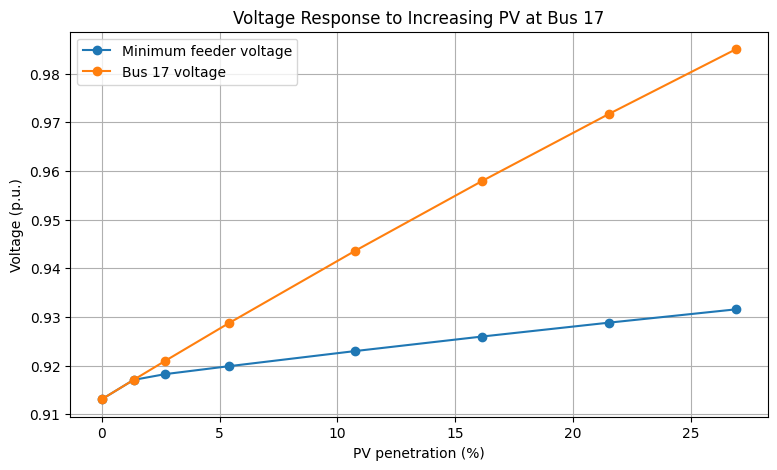

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(
    pv_sweep_df['PV penetration (%)'],
    pv_sweep_df['Minimum voltage (p.u.)'],
    marker='o',
    label='Minimum feeder voltage'
)

plt.plot(
    pv_sweep_df['PV penetration (%)'],
    pv_sweep_df['Bus 17 voltage (p.u.)'],
    marker='o',
    label='Bus 17 voltage'
)

plt.xlabel('PV penetration (%)')
plt.ylabel('Voltage (p.u.)')
plt.title('Voltage Response to Increasing PV at Bus 17')
plt.legend()
plt.grid(True)
plt.show()

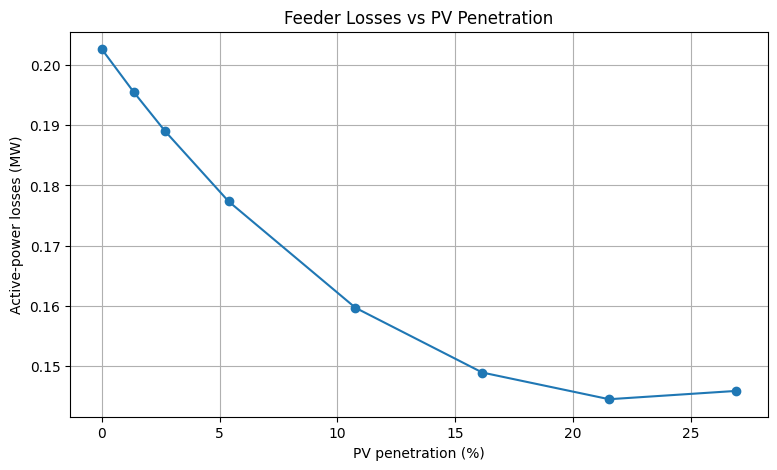

In [16]:
# Plot how feeder active-power losses change with PV penetration.
plt.figure(figsize=(9, 5))

plt.plot(
    pv_sweep_df['PV penetration (%)'],
    pv_sweep_df['Losses (MW)'],
    marker='o'
)

plt.xlabel('PV penetration (%)')
plt.ylabel('Active-power losses (MW)')
plt.title('Feeder Losses vs PV Penetration')
plt.grid(True)
plt.show()

The tested PV additions improve the low-voltage condition and initially reduce feeder losses. At higher penetration, the loss reduction stops and begins to reverse.

This shows PV integration cannot be evaluated using voltage alone. The amount and location of generation change both the voltage profile and the current flowing through the feeder.

## 4. Experiment 2: Effect of PV location

PV capacity is fixed at **0.40 MW** while the connection bus is changed.

Keeping PV capacity constant is important because it isolates the effect of location.

Several buses are tested across the feeder.

In [17]:
# Compare the effect of connecting the same 0.40 MW PV plant
# at several different buses.
pv_buses = [3, 6, 10, 14, 17, 24, 32]
location_results = []

for bus in pv_buses:
    net_test = pn.case33bw()

    pp.create_sgen(
        net_test,
        bus=bus,
        p_mw=0.40,
        q_mvar=0,
        name=f'PV_0.40MW_Bus{bus}'
    )

    pp.runpp(net_test)

    location_results.append({
        'PV bus': bus,
        'Minimum voltage (p.u.)': net_test.res_bus.vm_pu.min(),
        'PV bus voltage (p.u.)': net_test.res_bus.vm_pu.loc[bus],
        'Weakest bus': net_test.res_bus.vm_pu.idxmin(),
        'Losses (MW)': net_test.res_line.pl_mw.sum()
    })

pv_location_df = pd.DataFrame(location_results)

pv_location_df

,PV bus,Minimum voltage (p.u.),PV bus voltage (p.u.),Weakest bus,Losses (MW)
0,3,0.915754,0.977942,17,0.187640
1,6,0.919792,0.952636,17,0.172359
2,10,0.922934,0.943214,32,0.162868
3,14,0.923019,0.940293,32,0.158743
4,17,0.922999,0.943639,32,0.159630
5,24,0.914756,0.976723,17,0.186084
6,32,0.919479,0.935173,17,0.161528


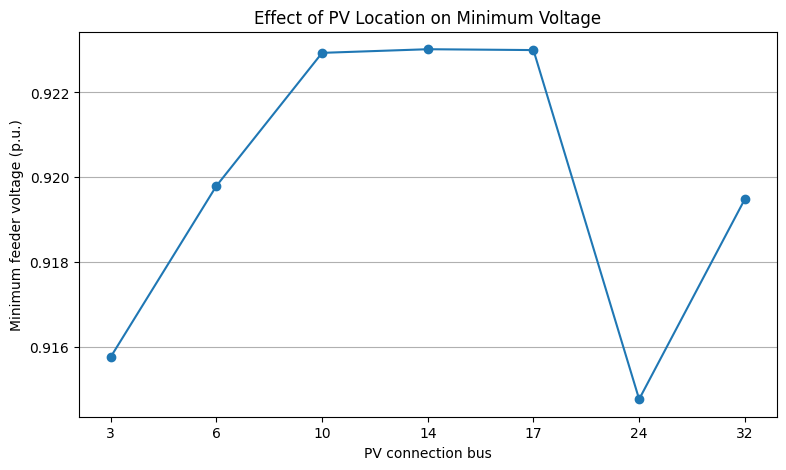

In [18]:
# Compare minimum feeder voltage for the different PV locations.
plt.figure(figsize=(9, 5))

plt.plot(
    pv_location_df['PV bus'].astype(str),
    pv_location_df['Minimum voltage (p.u.)'],
    marker='o'
)

plt.xlabel('PV connection bus')
plt.ylabel('Minimum feeder voltage (p.u.)')
plt.title('Effect of PV Location on Minimum Voltage')
plt.grid(axis='y')
plt.show()

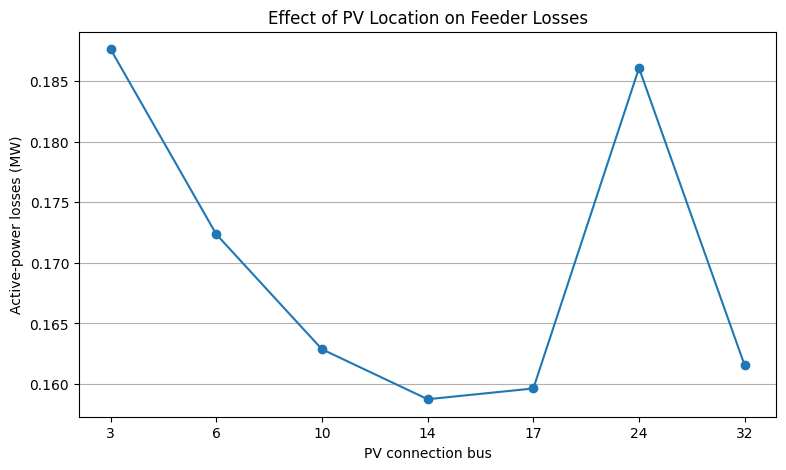

In [19]:
# Compare feeder losses for the different PV locations.
plt.figure(figsize=(9, 5))

plt.plot(
    pv_location_df['PV bus'].astype(str),
    pv_location_df['Losses (MW)'],
    marker='o'
)

plt.xlabel('PV connection bus')
plt.ylabel('Active-power losses (MW)')
plt.title('Effect of PV Location on Feeder Losses')
plt.grid(axis='y')
plt.show()


The same 0.40 MW PV capacity produces different voltage and loss results at different buses. This demonstrates that the electrical location of distributed generation matters.

## 5. Experiment 3: PV penetration at two locations

The location experiment showed that PV placement matters. Two locations are now examined, Bus 14 and Bus 17, over a range of PV capacities.

This experiment combines two variables that are central to PV integration:

- how much PV is installed
- where it is connected

In [20]:
# Compare increasing PV capacity at Bus 14 and Bus 17.
pv_sizes = [0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5]
comparison_buses = [14, 17]

penetration_results = []

for bus in comparison_buses:
    for pv_mw in pv_sizes:

        net_test = pn.case33bw()

        if pv_mw > 0:
            pp.create_sgen(
                net_test,
                bus=bus,
                p_mw=pv_mw,
                q_mvar=0,
                name=f'PV_{pv_mw}MW_Bus{bus}'
            )

        pp.runpp(net_test)

        penetration_results.append({
            'PV bus': bus,
            'PV size (MW)': pv_mw,
            'PV penetration (%)': (pv_mw / total_p_load) * 100,
            'Minimum voltage (p.u.)': net_test.res_bus.vm_pu.min(),
            'PV bus voltage (p.u.)': net_test.res_bus.vm_pu.loc[bus],
            'Weakest bus': net_test.res_bus.vm_pu.idxmin(),
            'Losses (MW)': net_test.res_line.pl_mw.sum()
        })

penetration_df = pd.DataFrame(penetration_results)

penetration_df

,PV bus,PV size (MW),PV penetration (%),Minimum voltage (p.u.),PV bus voltage (p.u.),Weakest bus,Losses (MW)
0,14,0.0,0.000000,0.913090,0.917093,17,0.202677
1,14,0.1,2.691790,0.918241,0.923036,32,0.189495
2,14,0.2,5.383580,0.919863,0.928881,32,0.177817
3,14,0.4,10.767160,0.923019,0.940293,32,0.158743
4,14,0.6,16.150740,0.926068,0.951357,32,0.145032
5,14,0.8,21.534320,0.929017,0.962100,32,0.136316
6,14,1.0,26.917900,0.931873,0.972545,32,0.132267
7,14,1.2,32.301480,0.934642,0.982712,32,0.132599
8,14,1.5,40.376851,0.938643,0.997481,32,0.140755
9,17,0.0,0.000000,0.913090,0.913090,17,0.202677


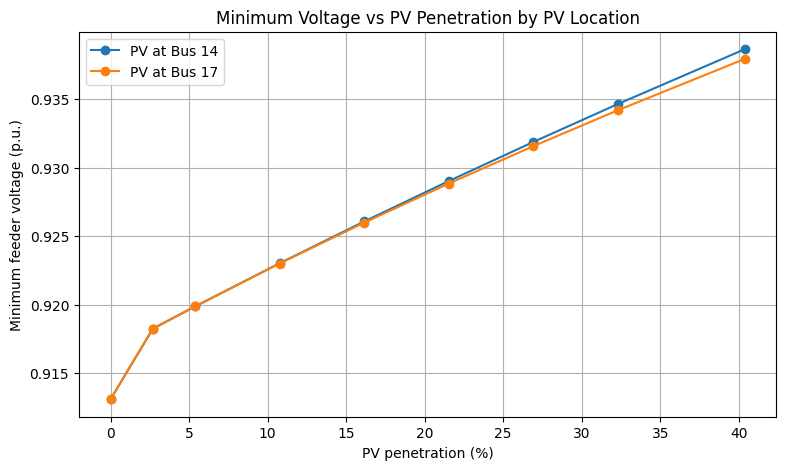

In [21]:
# Compare minimum voltage at Bus 14 and Bus 17 as PV penetration increases.
plt.figure(figsize=(9, 5))

for bus in comparison_buses:
    subset = penetration_df[penetration_df['PV bus'] == bus]

    plt.plot(
        subset['PV penetration (%)'],
        subset['Minimum voltage (p.u.)'],
        marker='o',
        label=f'PV at Bus {bus}'
    )

plt.xlabel('PV penetration (%)')
plt.ylabel('Minimum feeder voltage (p.u.)')
plt.title('Minimum Voltage vs PV Penetration by PV Location')
plt.legend()
plt.grid(True)
plt.show()

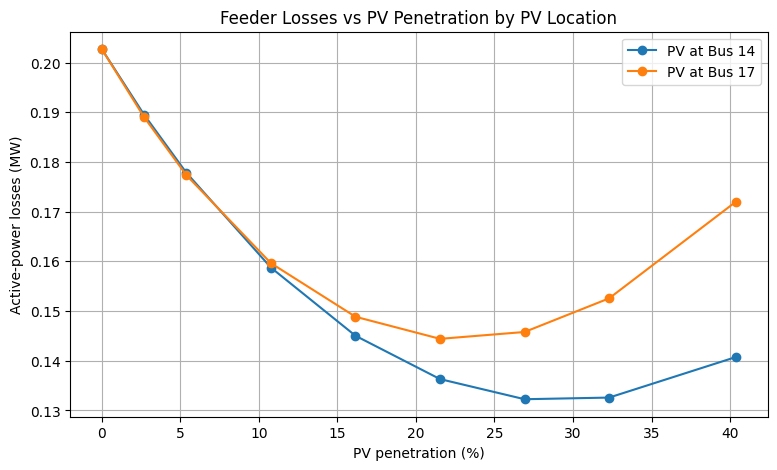

In [22]:
# Compare feeder losses for the two PV locations.
plt.figure(figsize=(9, 5))

for bus in comparison_buses:
    subset = penetration_df[penetration_df['PV bus'] == bus]

    plt.plot(
        subset['PV penetration (%)'],
        subset['Losses (MW)'],
        marker='o',
        label=f'PV at Bus {bus}'
    )

plt.xlabel('PV penetration (%)')
plt.ylabel('Active-power losses (MW)')
plt.title('Feeder Losses vs PV Penetration by PV Location')
plt.legend()
plt.grid(True)
plt.show()

## 6. Experiment 4: Active-power flow at high PV penetration

The previous comparison shows that Bus 17 becomes useful as a stress case at high PV output. At 1.5 MW of PV at Bus 17, the PV capacity is about 40.38% of the feeder total active load.

Line-end active-power flows are inspected to determine whether some sections of the feeder carry power opposite to their defined `from_bus -> to_bus` orientation.

A negative `p_from_mw` together with a positive `p_to_mw` indicates that the active-power flow is opposite to the stored line orientation.

In [23]:
# Create the 1.5 MW PV case used for the high-penetration power-flow study.
net_high_pv = pn.case33bw()

pp.create_sgen(
    net_high_pv,
    bus=17,
    p_mw=1.5,
    q_mvar=0,
    name='PV_1.5MW_Bus17'
)

pp.runpp(net_high_pv)

# Combine line orientation with calculated active-power flow.
line_flow = pd.concat(
    [
        net_high_pv.line[['from_bus', 'to_bus']].reset_index(drop=True),
        net_high_pv.res_line[
            ['p_from_mw', 'p_to_mw', 'q_from_mvar', 'q_to_mvar', 'pl_mw']
        ].reset_index(drop=True)
    ],
    axis=1
)

# Identify lines where active power flows opposite to the stored orientation.
reverse_flow = line_flow[
    (line_flow['p_from_mw'] < 0) &
    (line_flow['p_to_mw'] > 0)
]

print('Lines with reverse active-power flow:')
reverse_flow

Lines with reverse active-power flow:


,from_bus,to_bus,p_from_mw,p_to_mw,q_from_mvar,q_to_mvar,pl_mw
5,5,6,-0.357830,0.358393,0.570844,-0.568983,0.000563
6,6,7,-0.558393,0.560910,0.468983,-0.468151,0.002517
7,7,8,-0.760910,0.765787,0.368151,-0.364647,0.004878
8,8,9,-0.825787,0.831290,0.344647,-0.340746,0.005503
9,9,10,-0.891290,0.892442,0.320746,-0.320365,0.001152
10,10,11,-0.937442,0.939791,0.290365,-0.289588,0.002350
11,11,12,-0.999791,1.009933,0.254588,-0.246610,0.010141
12,12,13,-1.069933,1.074050,0.211610,-0.206189,0.004118
13,13,14,-1.194050,1.199467,0.126189,-0.121369,0.005416
14,14,15,-1.259467,1.266989,0.111369,-0.105875,0.007523


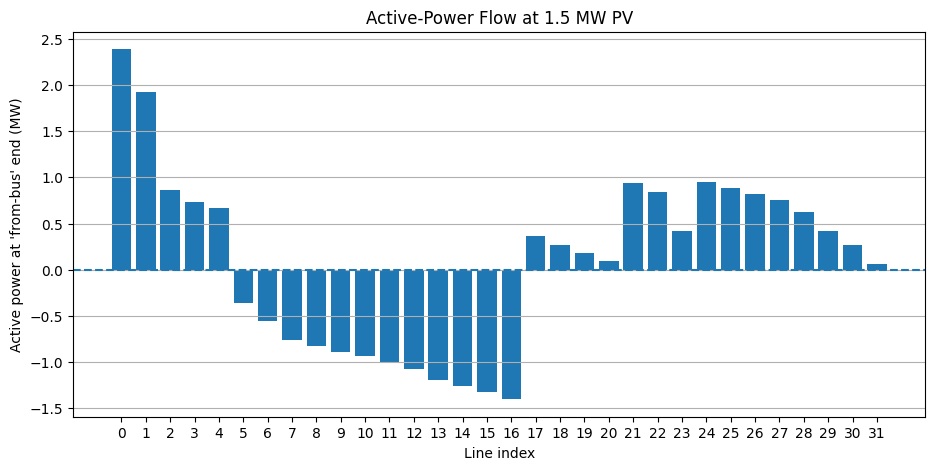

In [24]:
# Plot active power at the from-bus end of every active line.
# Negative values indicate flow opposite to the stored line orientation.
active_lines = line_flow[line_flow['pl_mw'] > 0].copy()

plt.figure(figsize=(11, 5))

plt.bar(
    active_lines.index.astype(str),
    active_lines['p_from_mw']
)

plt.axhline(0, linestyle='--')

plt.xlabel('Line index')
plt.ylabel('Active power at \'from-bus\' end (MW)')
plt.title('Active-Power Flow at 1.5 MW PV')
plt.grid(axis='y')
plt.show()

## 7. Experiment 5: Fixed reactive-power sensitivity

Before implementing closed-loop Volt-VAR control, several fixed values of reactive power are tested at the 1.5 MW PV plant.

For a generator in this model:

- positive Q means reactive-power injection
- negative Q means reactive-power absorption

This experiment helps to understand the voltage and loss response before introducing feedback control.

In [25]:
# Test fixed reactive-power settings for the 1.5 MW PV plant.
q_values = [0, -0.1, -0.2, -0.3, -0.4, -0.5]
q_results = []

for q in q_values:

    net_test = pn.case33bw()

    pp.create_sgen(
        net_test,
        bus=17,
        p_mw=1.5,
        q_mvar=q,
        name=f'PV_1.5MW_Q{q}'
    )

    pp.runpp(net_test)

    q_results.append({
        'Q (MVAr)': q,
        'Minimum voltage (p.u.)': net_test.res_bus.vm_pu.min(),
        'Maximum voltage (p.u.)': net_test.res_bus.vm_pu.max(),
        'Bus 17 voltage (p.u.)': net_test.res_bus.vm_pu.loc[17],
        'Losses (MW)': net_test.res_line.pl_mw.sum()
    })

q_df = pd.DataFrame(q_results)
q_df

,Q (MVAr),Minimum voltage (p.u.),Maximum voltage (p.u.),Bus 17 voltage (p.u.),Losses (MW)
0,0.0,0.937933,1.016322,1.016322,0.172010
1,-0.1,0.936873,1.010423,1.010423,0.181457
2,-0.2,0.935779,1.004401,1.004401,0.192556
3,-0.3,0.934652,1.000000,0.998251,0.205375
4,-0.4,0.933489,1.000000,0.991967,0.219985
5,-0.5,0.932288,1.000000,0.985542,0.236464


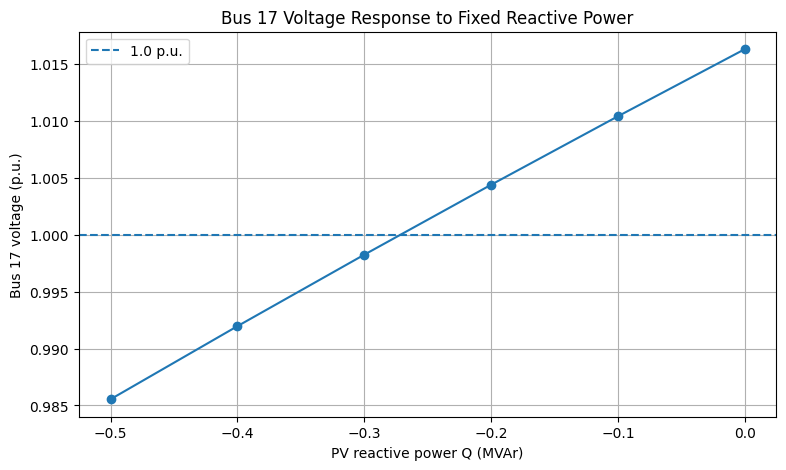

In [26]:
# Plot Bus 17 voltage against fixed reactive-power settings.
plt.figure(figsize=(9, 5))

plt.plot(
    q_df['Q (MVAr)'],
    q_df['Bus 17 voltage (p.u.)'],
    marker='o'
)

plt.axhline(1.0, linestyle='--', label='1.0 p.u.')

plt.xlabel('PV reactive power Q (MVAr)')
plt.ylabel('Bus 17 voltage (p.u.)')
plt.title('Bus 17 Voltage Response to Fixed Reactive Power')
plt.legend()
plt.grid(True)
plt.show()

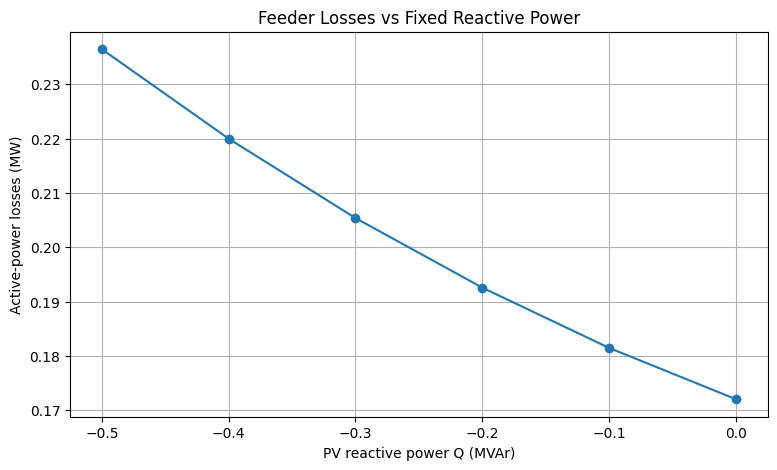

In [27]:
# Plot the corresponding feeder losses.
plt.figure(figsize=(9, 5))

plt.plot(
    q_df['Q (MVAr)'],
    q_df['Losses (MW)'],
    marker='o'
)

plt.xlabel('PV reactive power Q (MVAr)')
plt.ylabel('Active-power losses (MW)')
plt.title('Feeder Losses vs Fixed Reactive Power')
plt.grid(True)
plt.show()

## 8. Experiment 6: Illustrative Volt-VAR control

A Volt-VAR controller changes inverter reactive power according to the measured voltage.

The illustrative control curve used here is:

- below 0.98 p.u.: inject reactive power
- 0.98–1.00 p.u.: reduce injection toward zero
- 1.00–1.02 p.u.: increasingly absorb reactive power
- above 1.02 p.u.: maximum reactive-power absorption

These thresholds are **illustrative** and are not presented as a specific utility interconnection standard.

Because abrupt changes can cause the iterative calculation to oscillate, a damping factor is used. Instead of immediately applying the full target Q, the controller moves 25% of the way toward the target at each iteration.

In [28]:
# Define the illustrative Volt-VAR controller.
def volt_var_q(v_pu, q_max=0.5):
    # Positive Q = reactive-power injection.
    # Negative Q = reactive-power absorption.

    if v_pu <= 0.98:
        return q_max

    elif v_pu < 1.00:
        # Reduce reactive-power injection as voltage approaches 1.00 p.u.
        return q_max * (1.00 - v_pu) / (1.00 - 0.98)

    elif v_pu < 1.02:
        # Increase reactive-power absorption as voltage rises above 1.00 p.u.
        return -q_max * (v_pu - 1.00) / (1.02 - 1.00)

    else:
        return -q_max

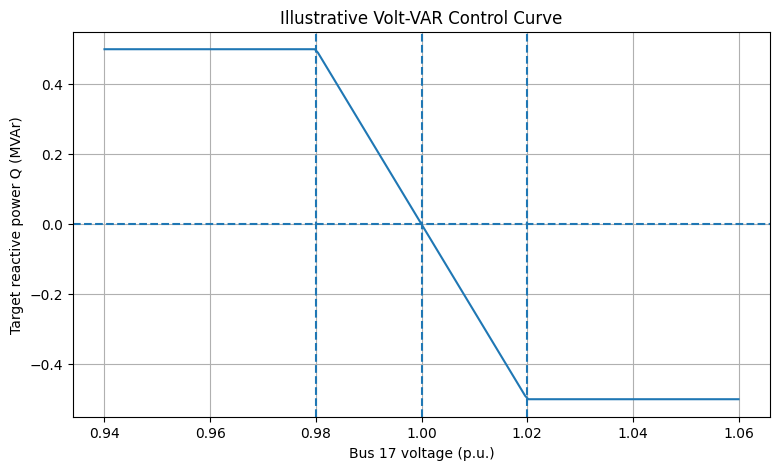

In [29]:
# Visualize the illustrative Volt-VAR curve before using it in a power flow.
test_voltages = np.linspace(0.94, 1.06, 200)
test_q = [volt_var_q(v) for v in test_voltages]

plt.figure(figsize=(9, 5))

plt.plot(test_voltages, test_q)

plt.axvline(0.98, linestyle='--')
plt.axvline(1.00, linestyle='--')
plt.axvline(1.02, linestyle='--')
plt.axhline(0, linestyle='--')

plt.xlabel('Bus 17 voltage (p.u.)')
plt.ylabel('Target reactive power Q (MVAr)')
plt.title('Illustrative Volt-VAR Control Curve')
plt.grid(True)
plt.show()

In [30]:
# Apply the Volt-VAR controller to the 1.5 MW PV case.
net_vv = pn.case33bw()

pv_index = pp.create_sgen(
    net_vv,
    bus=17,
    p_mw=1.5,
    q_mvar=0,
    name='PV_1.5MW_Bus17_VoltVAR'
)

history = []
alpha = 0.25

for iteration in range(50):

    pp.runpp(net_vv)

    voltage = net_vv.res_bus.vm_pu.loc[17]
    old_q = net_vv.sgen.loc[pv_index, 'q_mvar']

    target_q = volt_var_q(voltage)

    # Move only partway toward the target to reduce oscillation.
    new_q = old_q + alpha * (target_q - old_q)

    history.append({
        'iteration': iteration + 1,
        'voltage_pu': voltage,
        'q_mvar': old_q,
        'target_q_mvar': target_q
    })

    net_vv.sgen.loc[pv_index, 'q_mvar'] = new_q

    # Stop when the Q command has effectively stopped changing.
    if abs(new_q - old_q) < 0.0001:
        break

history_df = pd.DataFrame(history)
history_df

,iteration,voltage_pu,q_mvar,target_q_mvar
0,1,1.016322,0.000000,-0.408061
1,2,1.010302,-0.102015,-0.257562
2,3,1.007975,-0.140902,-0.199364
3,4,1.007095,-0.155517,-0.177369
4,5,1.006765,-0.160980,-0.169131
5,6,1.006642,-0.163018,-0.166056
6,7,1.006596,-0.163777,-0.164909
7,8,1.006579,-0.164060,-0.164482
8,9,1.006573,-0.164166,-0.164323


### Volt-VAR convergence

A successful iterative controller should settle toward a stable operating point rather than repeatedly switching between two different Q commands.

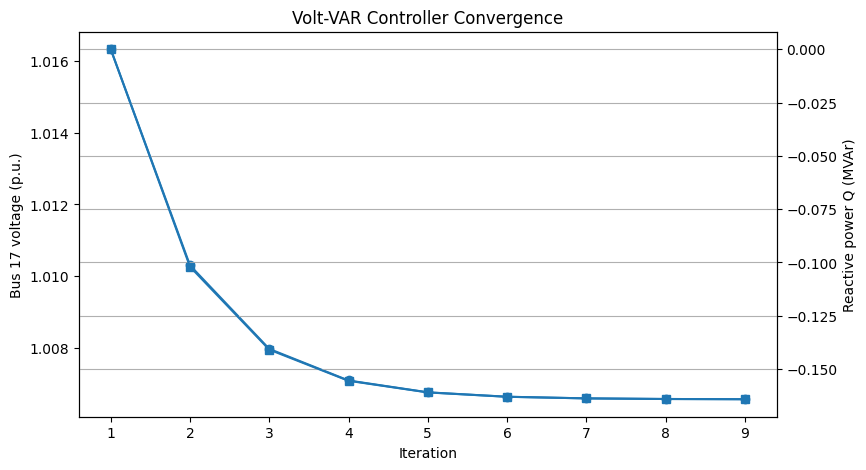

In [31]:
# Plot controller convergence.
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    history_df['iteration'],
    history_df['voltage_pu'],
    marker='o',
    label='Bus 17 voltage'
)

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Bus 17 voltage (p.u.)')

ax2 = ax1.twinx()

ax2.plot(
    history_df['iteration'],
    history_df['q_mvar'],
    marker='s',
    label='Reactive power'
)

ax2.set_ylabel('Reactive power Q (MVAr)')

plt.title('Volt-VAR Controller Convergence')
plt.grid(True)
plt.show()

In [32]:
# Run one final power flow using the converged reactive-power command.
pp.runpp(net_vv)

final_q = net_vv.sgen.loc[pv_index, 'q_mvar']
final_bus17_voltage = net_vv.res_bus.vm_pu.loc[17]
final_min_voltage = net_vv.res_bus.vm_pu.min()
final_max_voltage = net_vv.res_bus.vm_pu.max()
final_losses = net_vv.res_line.pl_mw.sum()

print(f'Final Q: {final_q:.4f} MVAr')
print(f'Bus 17 voltage: {final_bus17_voltage:.6f} p.u.')
print(f'Minimum voltage: {final_min_voltage:.6f} p.u.')
print(f'Maximum voltage: {final_max_voltage:.6f} p.u.')
print(f'Total losses: {final_losses:.6f} MW')

Final Q: -0.1642 MVAr
Bus 17 voltage: 1.006571 p.u.
Minimum voltage: 0.936174 p.u.
Maximum voltage: 1.006571 p.u.
Total losses: 0.188389 MW


## 9. Experiment 7: Full feeder voltage profile

The Bus 17 voltage is useful, but a distribution-network study should also examine what happens at the other buses.

The following are compared:

1. base case
2. 1.5 MW PV with Q = 0
3. 1.5 MW PV with the converged Volt-VAR Q

This shows whether the inverter's local voltage control also changes the wider feeder voltage profile.

In [33]:
# Base case
net_base = pn.case33bw()
pp.runpp(net_base)

# 1.5 MW PV without reactive-power control
net_no_control = pn.case33bw()

pp.create_sgen(
    net_no_control,
    bus=17,
    p_mw=1.5,
    q_mvar=0,
    name='PV_1.5MW_No_Control'
)

pp.runpp(net_no_control)

# Recreate the controlled network using the converged Q.
net_control = pn.case33bw()

pp.create_sgen(
    net_control,
    bus=17,
    p_mw=1.5,
    q_mvar=final_q,
    name='PV_1.5MW_VoltVAR'
)

pp.runpp(net_control)

voltage_comparison = pd.DataFrame({
    'Bus': net_base.bus.index,
    'Base case': net_base.res_bus.vm_pu.values,
    'PV no control': net_no_control.res_bus.vm_pu.values,
    'PV Volt-VAR': net_control.res_bus.vm_pu.values
})

voltage_comparison

,Bus,Base case,PV no control,PV Volt-VAR
0,0,1.000000,1.000000,1.000000
1,1,0.997032,0.997914,0.997853
2,2,0.982938,0.988543,0.988159
3,3,0.975456,0.984559,0.983939
4,4,0.968059,0.980808,0.979944
5,5,0.949658,0.970254,0.968555
6,6,0.946173,0.968415,0.966028
7,7,0.941328,0.970269,0.967602
8,8,0.935059,0.973576,0.970081
9,9,0.929244,0.977486,0.973182


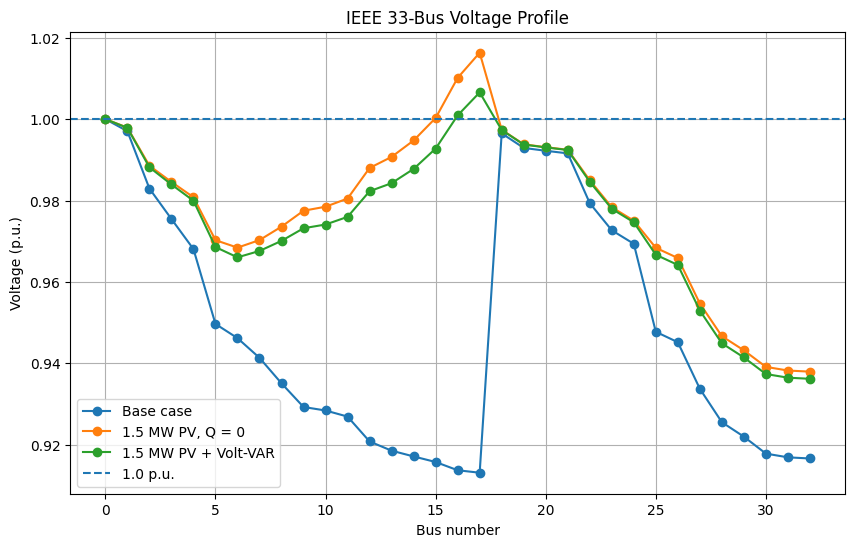

In [34]:
# Plot the complete feeder voltage profiles.
plt.figure(figsize=(10, 6))

plt.plot(
    voltage_comparison['Bus'],
    voltage_comparison['Base case'],
    marker='o',
    label='Base case'
)

plt.plot(
    voltage_comparison['Bus'],
    voltage_comparison['PV no control'],
    marker='o',
    label='1.5 MW PV, Q = 0'
)

plt.plot(
    voltage_comparison['Bus'],
    voltage_comparison['PV Volt-VAR'],
    marker='o',
    label='1.5 MW PV + Volt-VAR'
)

plt.axhline(1.0, linestyle='--', label='1.0 p.u.')

plt.xlabel('Bus number')
plt.ylabel('Voltage (p.u.)')
plt.title('IEEE 33-Bus Voltage Profile')
plt.legend()
plt.grid(True)
plt.show()

## 10. Inverter capability constraint

A real inverter cannot independently choose unlimited P and Q. Its apparent-power rating imposes:

$$
S = \sqrt{P^2 + Q^2}
$$

For this illustrative study, a **1.6 MVA inverter rating** is assumed. The Volt-VAR controller is also limited to ±0.5 MVAr.

The 1.6 MVA calculation is used to check that the controller's ±0.5 MVAr limit is physically achievable at each PV operating point. The controller does not use the full theoretical Q capability.

In [35]:
# Assumed apparent-power rating for the PV inverter.
S_rated = 1.6  # MVA

def q_capability(p_mw, s_rated=S_rated):
    # Maximum magnitude of reactive power available at a given P.
    return np.sqrt(max(s_rated**2 - p_mw**2, 0))

for pv_mw in [0.4, 0.8, 1.0, 1.2, 1.5]:
    q_cap = q_capability(pv_mw)

    print(
        f'PV = {pv_mw:.1f} MW | '
        f'Physical Q capability = ±{q_cap:.3f} MVAr'
    )

PV = 0.4 MW | Physical Q capability = ±1.549 MVAr
PV = 0.8 MW | Physical Q capability = ±1.386 MVAr
PV = 1.0 MW | Physical Q capability = ±1.249 MVAr
PV = 1.2 MW | Physical Q capability = ±1.058 MVAr
PV = 1.5 MW | Physical Q capability = ±0.557 MVAr


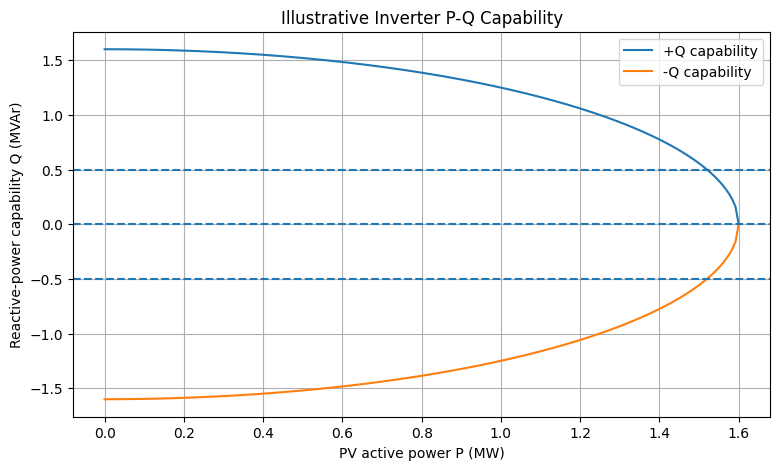

In [36]:
# Show how the physical Q capability changes with PV real-power output.
pv_capability = np.linspace(0, S_rated, 200)
q_capability_values = [q_capability(p) for p in pv_capability]

plt.figure(figsize=(9, 5))

plt.plot(pv_capability, q_capability_values, label='+Q capability')
plt.plot(pv_capability, -np.array(q_capability_values), label='-Q capability')

plt.axhline(0, linestyle='--')
plt.axhline(0.5, linestyle='--')
plt.axhline(-0.5, linestyle='--')

plt.xlabel('PV active power P (MW)')
plt.ylabel('Reactive-power capability Q (MVAr)')
plt.title('Illustrative Inverter P-Q Capability')
plt.legend()
plt.grid(True)
plt.show()

## 11. Experiment 8: Volt-VAR sensitivity to PV penetration

Finally, Volt-VAR analysis is repeated for several PV capacities at Bus 17.

This shows how the controller's required reactive power changes as PV penetration increases.

The same 1.6 MVA inverter rating and ±0.5 MVAr control limit are used. The actual Q command is clipped to the physical inverter capability.

In [37]:
def constrained_volt_var_q(v_pu, p_mw, s_rated=S_rated):
    # Limit the illustrative control range by the inverter's physical Q capability.
    q_cap = min(0.5, q_capability(p_mw, s_rated))

    if v_pu <= 0.98:
        return q_cap

    elif v_pu < 1.00:
        return q_cap * (1.00 - v_pu) / (1.00 - 0.98)

    elif v_pu < 1.02:
        return -q_cap * (v_pu - 1.00) / (1.02 - 1.00)

    else:
        return -q_cap

In [38]:
# Compare uncontrolled and controlled operation over several PV penetration levels.
pv_sizes = [0.4, 0.8, 1.0, 1.2, 1.5]
sensitivity_results = []

for pv_mw in pv_sizes:

    # Uncontrolled PV case: Q = 0.
    net_no_control = pn.case33bw()

    pp.create_sgen(
        net_no_control,
        bus=17,
        p_mw=pv_mw,
        q_mvar=0,
        name=f'PV_{pv_mw}MW_NoControl'
    )

    pp.runpp(net_no_control)

    uncontrolled_min_v = net_no_control.res_bus.vm_pu.min()
    uncontrolled_max_v = net_no_control.res_bus.vm_pu.max()
    uncontrolled_losses = net_no_control.res_line.pl_mw.sum()

    # Controlled PV case.
    net_control = pn.case33bw()

    pv_index = pp.create_sgen(
        net_control,
        bus=17,
        p_mw=pv_mw,
        q_mvar=0,
        name=f'PV_{pv_mw}MW_VoltVAR'
    )

    alpha = 0.25

    for iteration in range(50):

        pp.runpp(net_control)

        voltage = net_control.res_bus.vm_pu.loc[17]
        old_q = net_control.sgen.loc[pv_index, 'q_mvar']

        target_q = constrained_volt_var_q(
            voltage,
            p_mw=pv_mw,
            s_rated=S_rated
        )

        # Damping reduces abrupt changes in Q.
        new_q = old_q + alpha * (target_q - old_q)

        # Enforce the physical inverter capability.
        q_cap = q_capability(pv_mw, S_rated)
        new_q = np.clip(new_q, -q_cap, q_cap)

        net_control.sgen.loc[pv_index, 'q_mvar'] = new_q

        if abs(new_q - old_q) < 0.0001:
            break

    pp.runpp(net_control)

    controlled_min_v = net_control.res_bus.vm_pu.min()
    controlled_max_v = net_control.res_bus.vm_pu.max()
    controlled_losses = net_control.res_line.pl_mw.sum()

    final_q = net_control.sgen.loc[pv_index, 'q_mvar']
    bus17_voltage = net_control.res_bus.vm_pu.loc[17]
    actual_s = np.sqrt(pv_mw**2 + final_q**2)

    sensitivity_results.append({
        'PV size (MW)': pv_mw,
        'PV penetration (%)': (pv_mw / total_p_load) * 100,
        'Uncontrolled min V (p.u.)': uncontrolled_min_v,
        'Controlled min V (p.u.)': controlled_min_v,
        'Uncontrolled max V (p.u.)': uncontrolled_max_v,
        'Controlled max V (p.u.)': controlled_max_v,
        'Uncontrolled losses (MW)': uncontrolled_losses,
        'Controlled losses (MW)': controlled_losses,
        'Volt-VAR Q (MVAr)': final_q,
        'Controlled Bus 17 V (p.u.)': bus17_voltage,
        'Inverter S (MVA)': actual_s,
        'S rating (MVA)': S_rated,
        'Iterations': iteration + 1
    })

sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_df

,PV size (MW),PV penetration (%),Uncontrolled min V (p.u.),Controlled min V (p.u.),Uncontrolled max V (p.u.),Controlled max V (p.u.),Uncontrolled losses (MW),Controlled losses (MW),Volt-VAR Q (MVAr),Controlled Bus 17 V (p.u.),Inverter S (MVA),S rating (MVA),Iterations
0,0.4,10.767160,0.922999,0.927817,1.000000,1.000000,0.159630,0.140133,0.499718,0.973156,0.640092,1.6,26
1,0.8,21.534320,0.928834,0.931679,1.000000,1.000000,0.144414,0.128006,0.285748,0.988566,0.849501,1.6,10
2,1.0,26.917900,0.931567,0.933104,1.000000,1.000000,0.145795,0.135294,0.151162,0.993951,1.011360,1.6,9
3,1.2,32.301480,0.934189,0.934413,1.000000,1.000000,0.152564,0.150807,0.021543,0.999136,1.200193,1.6,7
4,1.5,40.376851,0.937933,0.936174,1.016322,1.006571,0.172010,0.188389,-0.164205,1.006571,1.508961,1.6,9


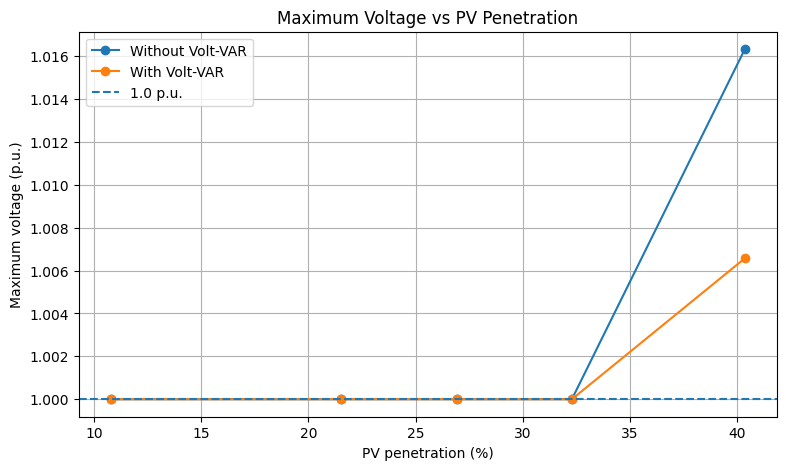

In [39]:
# Plot maximum voltage with and without Volt-VAR control.
plt.figure(figsize=(9, 5))

plt.plot(
    sensitivity_df['PV penetration (%)'],
    sensitivity_df['Uncontrolled max V (p.u.)'],
    marker='o',
    label='Without Volt-VAR'
)

plt.plot(
    sensitivity_df['PV penetration (%)'],
    sensitivity_df['Controlled max V (p.u.)'],
    marker='o',
    label='With Volt-VAR'
)

plt.axhline(1.0, linestyle='--', label='1.0 p.u.')

plt.xlabel('PV penetration (%)')
plt.ylabel('Maximum voltage (p.u.)')
plt.title('Maximum Voltage vs PV Penetration')
plt.legend()
plt.grid(True)
plt.show()

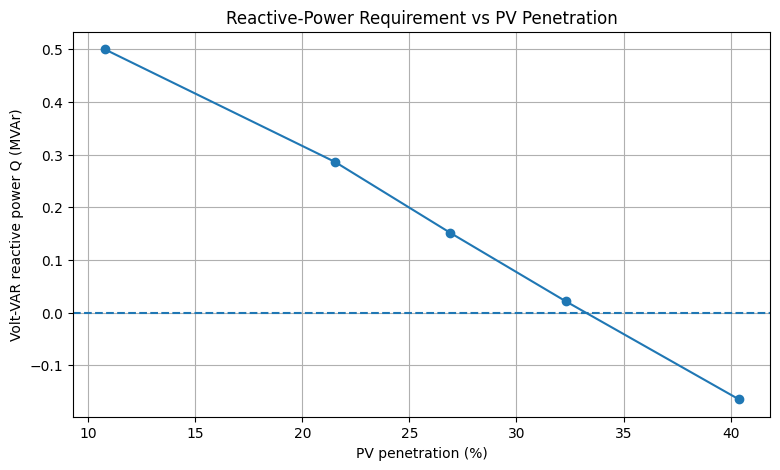

In [40]:
# Plot how the controller's reactive-power command changes
# from injection to absorption as PV penetration increases.
plt.figure(figsize=(9, 5))

plt.plot(
    sensitivity_df['PV penetration (%)'],
    sensitivity_df['Volt-VAR Q (MVAr)'],
    marker='o'
)

plt.axhline(0, linestyle='--')

plt.xlabel('PV penetration (%)')
plt.ylabel('Volt-VAR reactive power Q (MVAr)')
plt.title('Reactive-Power Requirement vs PV Penetration')
plt.grid(True)
plt.show()

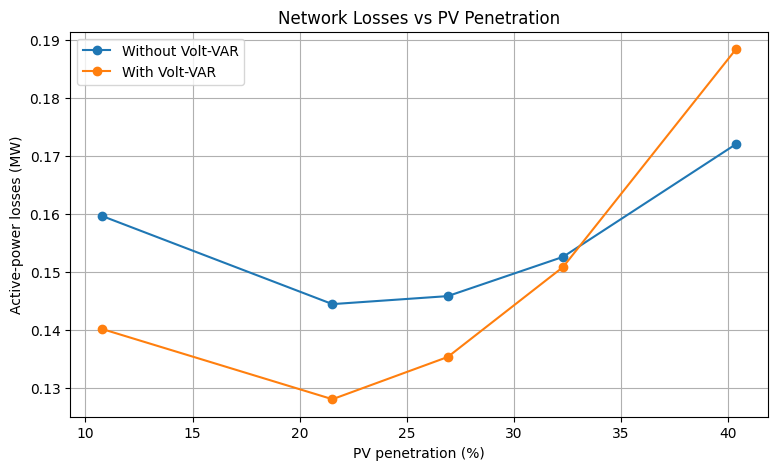

In [41]:
# Compare network losses with and without Volt-VAR control.
plt.figure(figsize=(9, 5))

plt.plot(
    sensitivity_df['PV penetration (%)'],
    sensitivity_df['Uncontrolled losses (MW)'],
    marker='o',
    label='Without Volt-VAR'
)

plt.plot(
    sensitivity_df['PV penetration (%)'],
    sensitivity_df['Controlled losses (MW)'],
    marker='o',
    label='With Volt-VAR'
)

plt.xlabel('PV penetration (%)')
plt.ylabel('Active-power losses (MW)')
plt.title('Network Losses vs PV Penetration')
plt.legend()
plt.grid(True)
plt.show()

## 12. Key findings


### PV penetration
Increasing PV at Bus 17 generally improves the feeder's low-voltage condition at the tested operating points. Losses initially decrease, then begin increasing at higher PV penetration.

### PV location
The same 0.40 MW PV capacity produces different voltage and loss results at different buses, showing that the electrical location of distributed generation matters.

### High PV penetration
At 1.5 MW at Bus 17, the uncontrolled case reaches a maximum voltage of about 1.0163 p.u. and exhibits reverse active-power flow on part of the feeder.

### Volt-VAR control
The illustrative controller changes from reactive-power injection at lower PV penetration to reactive-power absorption at higher PV penetration. At 1.5 MW, it reduces the Bus 17 voltage rise while changing the feeder loss level.


## 13. Limitations

This is a steady-state benchmark study, not a complete distribution-system hosting-capacity assessment.

Limitations are:

- PV output is represented by fixed operating points rather than time-series data
- the Volt-VAR curve is illustrative
- the inverter rating is an explicit modelling assumption
- realistic line thermal limits were not evaluated because the benchmark's supplied line current ratings are not meaningful physical limits for this study.
- unbalanced three-phase effects are not modeled


## 14. Conclusion

This study examined how distributed solar PV changes voltage profiles, losses, and active-power flow in the IEEE 33-bus distribution system. It also demonstrated how an inverter-based Volt-VAR controller can respond differently at different PV penetration levels.

The main value of the project is not a single numerical hosting-capacity limit. It is the demonstration of the relationships between PV location, penetration, feeder voltage, power losses, power-flow direction, and reactive-power control.

## 15.Reference
[1] L. Thurner et al., "pandapower — an Open Source Python Tool for Convenient Modeling, Analysis and Optimization of Electric Power Systems," in IEEE Transactions on Power Systems, vol. 33, no. 6, pp. 6510-6521, Nov. 2018.